---
# **Supervised Learning** - Handling SensorStats.csv
---

In [ ]:
import pandas as pd

df = pd.read_csv('data/SensorStats.csv')
df.head()

### EDA

In [ ]:
df.info()

**Note -**  "Remote Override Flag" and "Airborne Status" are left out as they are binary.

In [ ]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Selecting main features
features_to_plot = [
    'VOC Emissions', 'Acoustic / Vibration', 'CPU Utilization', 
    'Mechanical Load', 'Axis Elevation / Altitude', 'Actuator Torque', 
    'Thermal Load', 'Compromise Risk Index'
]

# 4. Set up the plotting grid (4 rows, 2 columns)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 24))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()

# 5. Loop through each feature, filter out zeros, and plot
for i, feature in enumerate(features_to_plot):
    # Filter: Keep only rows where THIS specific feature is greater than 0
    # We also drop NaNs just for the plot so seaborn doesn't complain
    active_data = df[df[feature] > 0].dropna(subset=[feature])
    
    sns.stripplot(
        data=active_data, 
        x='Asset Class', 
        y=feature, 
        ax=axes[i],
        jitter=True, 
        alpha=0.5,
        palette='Set1',
        size=4
    )
    
    axes[i].set_title(f'{feature} by Asset Class (Non-Zero)', fontsize=20, fontweight='bold')
    axes[i].set_ylabel(feature, fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Finding about Remote Override Flag and Airborne Status
def flag_details(df, cols):

    stats = df.groupby("Asset Class")[cols].agg(["sum", "count"])
    return stats.apply(
        lambda row: f"{int(row['sum'])} / {int(row['count'])}",
        axis=1
    )
 
print("\nRemote Override Flag")
print(flag_details(df, "Remote Override Flag"))
 
print("\nAirborne Status")
print(flag_details(df, "Airborne Status"))

In [ ]:
# Finding how many Compromise Risk Index which are non zeros and Override Active ofr robot_arm
arm_df = df[df['Asset Class'] == 'robot_arm']

print(f"\nTotal Robotic Arms        : {len(arm_df)}")
print(f"Override Flag Active      : {len(arm_df[arm_df['Remote Override Flag'] == 1])}")
print(f"Compromise Risk Index > 0 : {len(arm_df[arm_df['Compromise Risk Index'] > 0])}")

arms_both = len(arm_df[
    (arm_df['Remote Override Flag'] == 1) &
    (arm_df['Compromise Risk Index'] > 0)
])
print(f"Override Active AND Exposed: {arms_both} ")

In [ ]:
# Plotting All to single Graphs

# As we can see Robot Arms and AGV are divided based on Remote Override Flag and Airborne Status respectively
# So we categories to 7 category
def categorize_detailed(row):
    asset = row["Asset Class"]
    if asset == "robot_arm":
        return "Robotic Arm (Override)" if row["Remote Override Flag"] == 1 else "Robotic Arm (Non Override)"
    elif asset == "agv_units":
        return "AGV Unit (Fly)" if row["Airborne Status"] == 1 else "AGV Unit (No Fly)"
    elif asset == "cnc_machine":
        return "CNC Machine"
    elif asset == "plc_controller":
        return "PLC Controller"
    elif asset == "drone":
        return "Drone"
    return "Unknown"

df['Detailed Asset Class'] = df.apply(categorize_detailed, axis=1)

# Reshaping the data for seaborn graph
melted_df = pd.melt(
    df, 
    id_vars=['Detailed Asset Class'], 
    value_vars=features_to_plot,             
    var_name='Sensor Type',
    value_name='Sensor Value'
)

# Removing  NaN
active_df = melted_df[melted_df["Sensor Value"] > 0].dropna(subset=["Sensor Value"])
# Setting up a custom color palette for all 7 categories
custom_palette = {
    'Robotic Arm (Override)': 'mediumorchid',
    'Robotic Arm (Non Override)': 'darkgray',
    'AGV Unit (Fly)': 'crimson',
    'AGV Unit (No Fly)': 'royalblue',
    'CNC Machine': 'forestgreen',
    'PLC Controller': 'goldenrod',
    'Drone': 'teal'
}
 
# Building the plot
fig, ax = plt.subplots(figsize=(16, 10))
sns.stripplot(
    data=active_df,
    x="Sensor Type",
    y="Sensor Value",
    hue="Detailed Asset Class", # <--- Fixed this line
    jitter=True,
    palette=custom_palette,
    size=4,
    dodge=True,
    ax=ax,
)
 
ax.set_title(
    "Sentinel CPS — Physical Sensor Profiles by Detailed Asset Sub-Class",
    fontsize=20
)
ax.set_xlabel("Sensor Type",   fontsize=13, fontweight="bold")
ax.set_ylabel("Raw Sensor Value", fontsize=13, fontweight="bold")
ax.tick_params(axis="x",labelsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(
    title="Detailed Asset Sub-Class",
    title_fontsize=11,
    fontsize=10,
    markerscale=4,
    loc="upper right",
)
 
plt.tight_layout()
plt.savefig("sentinel_sensor_profiles.png", dpi=150)
plt.show()

In [ ]:
# Plotting All to single Graphs except Compromise Risk Index

# 2. Define the continuous features (EXCLUDING Compromise Risk Index)
features_to_plot = [
    'VOC Emissions', 'Acoustic / Vibration', 'CPU Utilization', 
    'Mechanical Load', 'Axis Elevation / Altitude', 'Actuator Torque', 'Thermal Load'
]

# As we can see Robot Arms and AGV are divided based on Remote Override Flag and Airborne Status respectively
# So we categories to 7 category
def categorize_detailed(row):
    asset = row["Asset Class"]
    if asset == "robot_arm":
        return "Robotic Arm (Override)" if row["Remote Override Flag"] == 1 else "Robotic Arm (Non Override)"
    elif asset == "agv_units":
        return "AGV Unit (Fly)" if row["Airborne Status"] == 1 else "AGV Unit (No Fly)"
    elif asset == "cnc_machine":
        return "CNC Machine"
    elif asset == "plc_controller":
        return "PLC Controller"
    elif asset == "drone":
        return "Drone"
    return "Unknown"

df['Detailed Asset Class'] = df.apply(categorize_detailed, axis=1)

# Reshaping the data for seaborn graph
melted_df = pd.melt(
    df, 
    id_vars=['Detailed Asset Class'], 
    value_vars=features_to_plot,             
    var_name='Sensor Type',
    value_name='Sensor Value'
)

# Removing  NaN
active_df = melted_df[melted_df["Sensor Value"] > 0].dropna(subset=["Sensor Value"])
# Setting up a custom color palette for all 7 categories
custom_palette = {
    'Robotic Arm (Override)': 'mediumorchid',
    'Robotic Arm (Non Override)': 'darkgray',
    'AGV Unit (Fly)': 'crimson',
    'AGV Unit (No Fly)': 'royalblue',
    'CNC Machine': 'forestgreen',
    'PLC Controller': 'goldenrod',
    'Drone': 'teal'
}
 
# Building the plot
fig, ax = plt.subplots(figsize=(16, 10))
sns.stripplot(
    data=active_df,
    x="Sensor Type",
    y="Sensor Value",
    hue="Detailed Asset Class", # <--- Fixed this line
    jitter=True,
    palette=custom_palette,
    size=4,
    dodge=True,
    ax=ax,
)
 
ax.set_title(
    "Sentinel CPS — Physical Sensor Profiles by Detailed Asset Sub-Class",
    fontsize=20
)
ax.set_xlabel("Sensor Type",   fontsize=13, fontweight="bold")
ax.set_ylabel("Raw Sensor Value", fontsize=13, fontweight="bold")
ax.tick_params(axis="x",labelsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(
    title="Detailed Asset Sub-Class",
    title_fontsize=11,
    fontsize=10,
    markerscale=4,
    loc="upper right",
)
 
plt.tight_layout()
plt.savefig("sentinel_sensor_profiles.png", dpi=150)
plt.show()

### **Observation**
1. Dataset Composition**
    - 10,000 total entries across 5 asset classes, 2,000 per class.
    - Continuous telemetry features contain minor missing values (range: 9,959–9,975 non-null out of 10,000). Binary columns (Remote Override Flag, Airborne Status) and Compromise Risk Index are complete with 10,000 non-null entries.
    - Missing value strategy: median imputation to be applied prior to model training.
2. Airborne Status Distribution
    - All 2,000 Inspection Drone entries have Airborne Status = 1.
    - AGV Unit entries are split: 961 with Airborne Status = 1, 1,039 with Airborne Status = 0.
    - AGV Unit which can fly have more mechanical load than non flying AGV, maybe due to battery weight. It looks like above 350.
    - All remaining asset classes (Robotic Arm, CNC Machine, PLC Controller) have Airborne Status = 0 throughout.
3. Compromise Risk Index
    - Non-zero Compromise Risk Index values are present exclusively in the Robotic Arm class. All other asset classes register 0.00 across all 8,000 entries.
    - Within the 2000 Robotic Arm entries: all 2000 carry a Compromise Risk Index > 0, forming two distinct value bands. 
    - The upper band (approx. 5,000–7,000) corresponds exactly to the 500 entries where Remote Override Flag = 1. The lower band corresponds to the remaining 1,500 entries where Remote Override Flag = 0.


### **Conclusion**
We must strictly exclude the Remote Override Flag, Airborne Status, and Compromise Risk Index from the feature set used to train the Supervised Learning (SL) models mainly due to 2 reasons:
* **Prevention of Target Leakage:** Including risk or override flags acts as an "answer key." This causes artificial 100% accuracy and prevents the model from learning true physical anomaly signatures.
* **Preservation of Ground Truth:** Withholding these deterministic columns creates an independent, uncorrupted validation layer. We can use these to verfy later.

## Model Selection for Supervised Learning

In [ ]:
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

features = [
    'VOC Emissions', 'Acoustic / Vibration', 'CPU Utilization', 
    'Mechanical Load', 'Axis Elevation / Altitude', 'Actuator Torque', 'Thermal Load'
]

x = df[features]
y = df['Asset Class'] # Updated to use the industrial mapped column

# Replacing missing sensor packets  with 0
x = x.fillna(0)

# Train-Test Split (80/20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 6. Initializing the Supervised Learning Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Train and Evaluate Each Model
results = []

for name, model in models.items():
    start_time = time.perf_counter()
    
    # Train
    model.fit(x_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(x_test_scaled)
    elapsed = time.perf_counter() - start_time

    # Calculate Metrics (Macro average computes the metric independently for each asset class)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Time (s)": elapsed
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("SUPERVISED LEARNING LEADERBOARD")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

#### **We are selecting Random Forest and SVM (RBF Kernel)** Reason Explained in Report

---
# **Unsupervised Learning** - Image Handling
---

In [1]:
import os
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from src.usl_feature_extractor import get_feature
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# EVALUTION FUNCTION
def get_clustering_metrics(true_labels, raw_clusters, method_name):
    """Calculates standard unsupervised metrics from raw cluster assignments."""
    return {
        "Method": method_name,
        "ARI": adjusted_rand_score(true_labels, raw_clusters),
        "NMI": normalized_mutual_info_score(true_labels, raw_clusters),
        "Homogeneity": homogeneity_score(true_labels, raw_clusters)
    }
    return pd.concat([df, row], ignore_index=True)

# Maps arbitrary cluster numbers to the majority Asset Class
def map_clusters_to_truth(true_labels, cluster_labels):
    mapped_labels = np.empty_like(cluster_labels, dtype=object)
    for c in np.unique(cluster_labels):
        # Find all images assigned to this cluster
        mask = (cluster_labels == c)
        # What is the most common actual asset in this cluster?
        if np.any(mask):
            majority_label = pd.Series(true_labels[mask]).mode()[0]
            mapped_labels[mask] = majority_label
    return mapped_labels

### Different USL model

In [3]:
def seed_everything(seed=42):
    # Standard Python/Library seeds
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Call this ONCE at the very top of your notebook
seed_everything(42)

In [4]:
# Getting Features from src file.
df_pca = get_feature(base_dir="data/fantasy_dataset", use_pca=True)
df_umap = get_feature(base_dir="data/fantasy_dataset", use_pca=False)
print(df_pca.head())
print(df_umap.head())


FEATURE PIPELINE INITIATED
Got 8018 images in 'data/fantasy_dataset'
Preparing Images for CAE Inference
  -> CAE Features Extracted: (8018, 128)
  -> CV Extraction for 8018 images


CV feature Extractor: 100%|██████████| 8018/8018 [00:15<00:00, 527.07it/s] 



Applying PCA compression

Pipeline complete.
Final PCA Fused Tensor Shape: (8018, 62)

FEATURE PIPELINE INITIATED
Got 8018 images in 'data/fantasy_dataset'
Preparing Images for CAE Inference
  -> CAE Features Extracted: (8018, 128)
  -> CV Extraction for 8018 images


CV feature Extractor: 100%|██████████| 8018/8018 [00:15<00:00, 529.96it/s] 



Applying UMAP compression


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



Pipeline complete.
Final UMAP Fused Tensor Shape: (8018, 62)
                image_name     Asset Class  \
0  plc_controller_F165.png  plc_controller   
1  plc_controller_E283.png  plc_controller   
2  plc_controller_E158.png  plc_controller   
3  plc_controller_A090.png  plc_controller   
4  plc_controller_F043.png  plc_controller   

                                      fused_features  
0  [0.03537927287100451, 0.0019172099881141125, 0...  
1  [-1.0152081809738998, 0.2623933722055891, -0.1...  
2  [-0.7051694983608883, -0.07803836169853687, 0....  
3  [-0.050216599626054195, -1.3363743504782704, -...  
4  [-0.9620582329891139, 0.00759033675710734, -0....  
                image_name     Asset Class  \
0  plc_controller_F165.png  plc_controller   
1  plc_controller_E283.png  plc_controller   
2  plc_controller_E158.png  plc_controller   
3  plc_controller_A090.png  plc_controller   
4  plc_controller_F043.png  plc_controller   

                                      fused_features  

In [5]:
# Extract Data for Clustering
X_pca = np.array(df_pca['fused_features'].tolist())
X_umap = np.array(df_umap['fused_features'].tolist())
true_labels = df_pca['Asset Class'].values
unique_classes = np.unique(true_labels)
n_clusters = len(unique_classes)

In [6]:
# Running GMM
def run_gmm_analysis(x):
    gmm = GaussianMixture(n_components=5, covariance_type='spherical', random_state=42, n_init=10)
    gmm.fit(x)
    probs = gmm.predict_proba(x)
    clusters = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)
    return clusters, confidences, probs

print("\nProcessing GMM on both reducers")
clusters_pca, conf_pca, p_mat_pca = run_gmm_analysis(X_pca)
clusters_umap, conf_umap, p_mat_umap = run_gmm_analysis(X_umap)


Processing GMM on both reducers



--- Sentinel-CPS: Clustering Evaluation Metrics ---


,Method,ARI,NMI,Homogeneity
0,GMM + PCA (k=5),0.2873,0.460,0.4549
1,GMM + UMAP (k=5),0.3146,0.437,0.4281


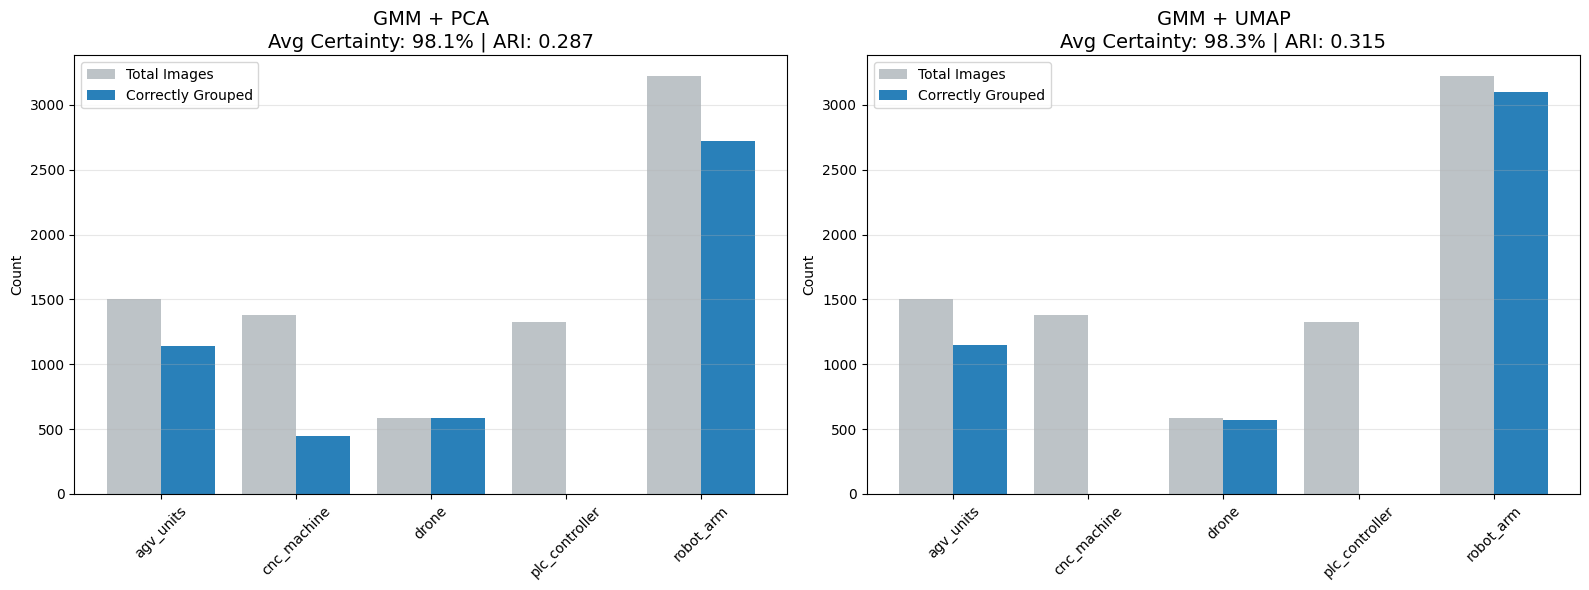


Found 168 images with low classification confidence.
These are potential 'OOD' (Out of Distribution) anomalies for your report.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_gmm_results(ax, x, clusters, conf, title):
    # Mapping clusters to Asset Names for the plot (Matches majority true label in each cluster)
    mapped_preds = np.empty_like(clusters, dtype=object)
    for c in np.unique(clusters):
        mask = (clusters == c)
        if np.any(mask):
            majority = pd.Series(true_labels[mask]).mode()[0]
            mapped_preds[mask] = majority
            
    # Calculate Metrics
    ari = adjusted_rand_score(true_labels, clusters)
    avg_conf = np.mean(conf) * 100
    
    # Plot bars: Total vs Correct
    x_indices = np.arange(len(unique_classes))
    totals = [np.sum(true_labels == cls) for cls in unique_classes]
    corrects = [np.sum((true_labels == cls) & (mapped_preds == cls)) for cls in unique_classes]
    
    ax.bar(x_indices - 0.2, totals, width=0.4, label='Total Images', color='#bdc3c7')
    ax.bar(x_indices + 0.2, corrects, width=0.4, label='Correctly Grouped', color='#2980b9')
    
    ax.set_title(f"GMM + {title}\nAvg Certainty: {avg_conf:.1f}% | ARI: {ari:.3f}", fontsize=14)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(unique_classes, rotation=45)
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Final Results
metrics_pca = get_clustering_metrics(true_labels, clusters_pca, "GMM + PCA (k=5)")
metrics_umap = get_clustering_metrics(true_labels, clusters_umap, "GMM + UMAP (k=5)")
results_df = pd.DataFrame([metrics_pca, metrics_umap])
print("\n--- Sentinel-CPS: Clustering Evaluation Metrics ---")
display(results_df.round(4))

plot_gmm_results(axes[0], X_pca, clusters_pca, conf_pca, "PCA")
plot_gmm_results(axes[1], X_umap, clusters_umap, conf_umap, "UMAP")
plt.tight_layout()
plt.show()


# Let's find images where GMM was "confused" (Certainty < 70%)
low_conf_mask = conf_pca < 0.70
print(f"\nFound {np.sum(low_conf_mask)} images with low classification confidence.")
if np.sum(low_conf_mask) > 0:
    print("These are potential 'OOD' (Out of Distribution) anomalies for your report.")

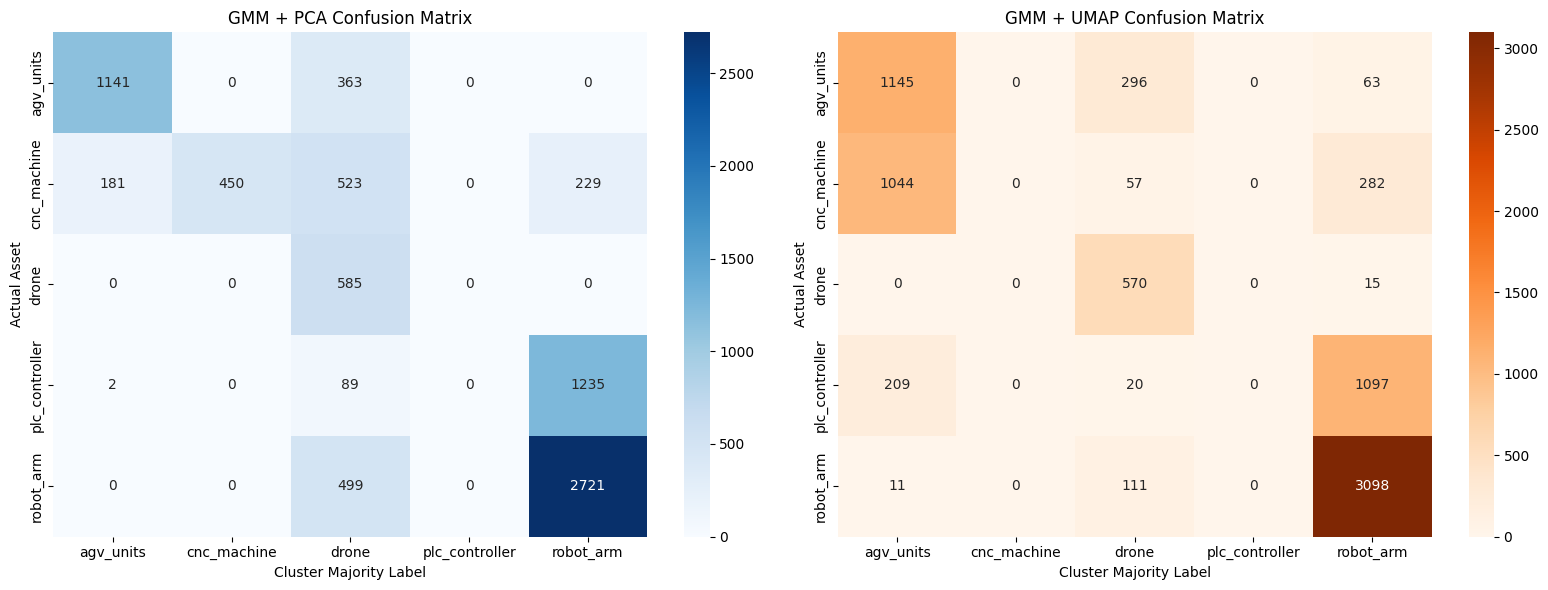

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

pred_labels_pca = map_clusters_to_truth(true_labels, clusters_pca)
pred_labels_umap = map_clusters_to_truth(true_labels, clusters_umap)

# 2. Set up the side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. PCA Confusion Matrix
cm_pca = confusion_matrix(true_labels, pred_labels_pca, labels=unique_classes)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_classes, yticklabels=unique_classes, ax=axes[0])
axes[0].set_title('GMM + PCA Confusion Matrix')
axes[0].set_ylabel('Actual Asset')
axes[0].set_xlabel('Cluster Majority Label')

# 4. UMAP Confusion Matrix
cm_umap = confusion_matrix(true_labels, pred_labels_umap, labels=unique_classes)
sns.heatmap(cm_umap, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=unique_classes, yticklabels=unique_classes, ax=axes[1])
axes[1].set_title('GMM + UMAP Confusion Matrix')
axes[1].set_ylabel('Actual Asset')
axes[1].set_xlabel('Cluster Majority Label')

plt.tight_layout()
plt.show()